# Day 16 - Lecture 13

We are finally starting to get into Machine Learning!

**Using Izevic, pages 3-5**

#### What is Machine Learning?

It is a set of techniques that we use for interpreting data by comparing them to models for data behaviour.

This can include:
1. Various regression methods
2. Supervised Classification
3. Maximum likelihood estimators
4. Bayesian methods

Usually, the use of machine learning can be for prediction of one variable based on another variable. 

**Machine Learning for Physics and Astronomy Chapter 1**

Machine learning is the process of teaching a mchine to make informed, data driven decisions. Such as recognising and characterizing objects based on similar criteria, detecting patterns and distinguishing signals from noise.

Machine learning tools are used for:
1. **Recognition** of an instance of a certain type such as saying a dog is a dog
2. **Predict** some property or information on the basis of other information
3. **Grouping** objects that are similar, or single out objects that are dissimilar (clustering)
4. **Simplify** information in a complicated data set to condense it to its quintessential nature.


### Let us get our terminology straight

Elements within a data set are known as instances, samples or examples. Features are properties that are known about the instances. Usually these are things that can be measured, simulated, or observed within experiment.

Usually we organise data in rows and columns, where each row describes an instance, and each column contains the measured value of one feature associated with that instance. Hence the total size of the data set is the number of features, multiplied by the number of instances. If we wish to estimate or predict a property based on the features, this is called the target or output.

Our goal for ML is to build a relationship between input and output through a model. Where a model allows us to go from input space of features to the output space of targets.

### Supervised Learning 

Here we assume that there is a collection of istances for which the target property is known. This collection is known as the learning set and the ML uses these to infer the rule that connects the features to the output.

This means that a supervised learning method is only as good as it's learning set.

It is customary to set aside a subset of the learning set that does not participate in the model building. Once the training is complete, we can use the modle to make predictions of the target property of those obhects and verify if they are correct.

The **performance** of a model can be expressed as the rate of failure (error) or rate of success (score). And to ensure good results we want out learning sets to be large enough and representitive of our application domain, and organised in a way that optimizes the information content for the task.

#### Classification vs Regression

These two methods only differ in the output part:
1. In classification, the target property belongs to a discrete set of possibilites (a class)

For example, correctly identifying a fruit in a bag on the basis of properties that can be measured through touch, such as height, weidth, shape, etc. The output can only be a specific fruit so our output response is either 100% right or 100% wrong.

When evaluating the formance, we count the number of correct answers.

2. In regression, the output is continuous (usually a real number)

Hence, in regressiont asks we can only evaluate the model by assessing how close we are to the correct value.

### Unsupervised learning

Here, we are trying to discover patterns in the data.

#### Clustering

We can use unsupervised learning for counting or grouping objects in a smart way. 

For example, we can cluster galaxies into different groups such as spiral, elliptical or irregular

#### Dimensionality reduction

These techniques are used to make a data set smaller, and hence more manageable with minimal information loss.

This works in one of 3 ways:
1. The simplest approach involves retaining the original features and just selecting those that are expected to be more meaningful
2. Or we can remap the feature space to a different one. In which fewer components can express the highest amount of variance of the original data
3. Finally, we can learn a manifold, which is a nonlinear space in which some interesting properties of the original data set are preserved.


The best parts of machine learning come from mix and matching different techniques

## L13 - Introduction

Now we shall go onto Lecture 13.

Let us start with Sci-kit learn for machine learning/data mining

First we will look at a classification task

The figure shows a collection of two-dimensional data, colored according to two different class labels. We wish to determine a classification algorithm that can be used to draw a dividing boundary between the two clusters of points:

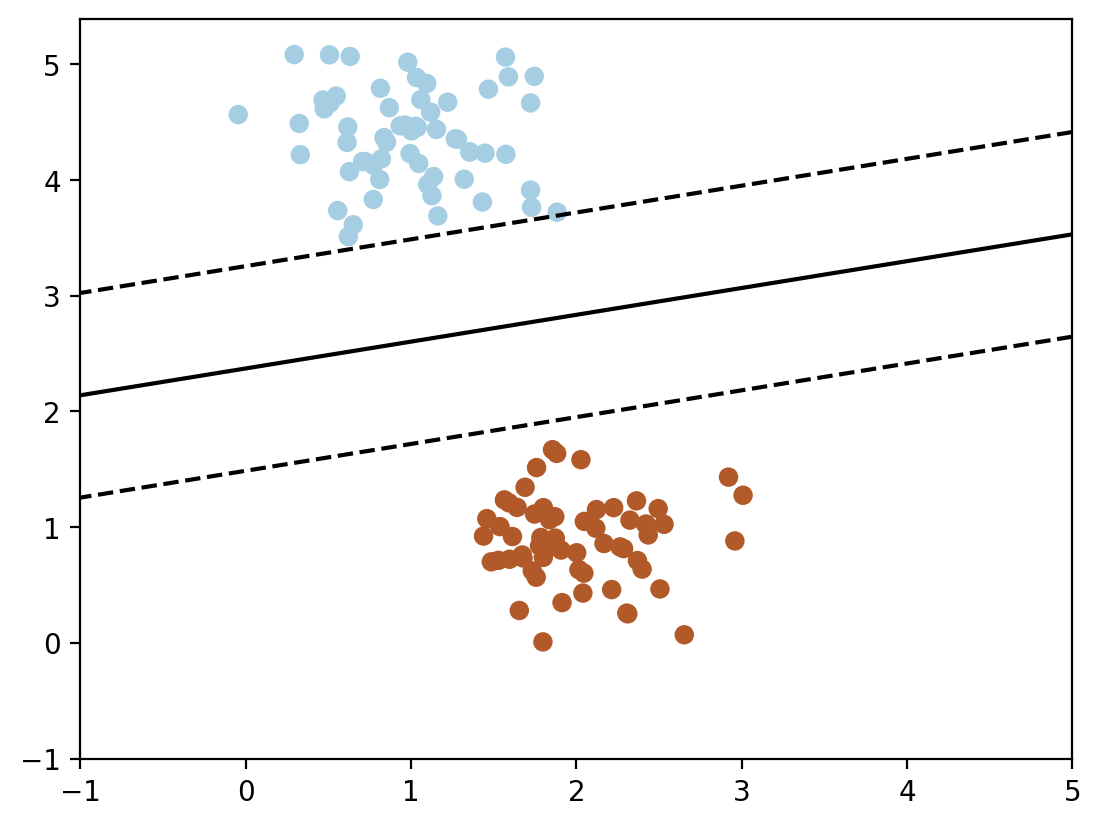

In [125]:
from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'

# G. Richards 2016, based on sgd_separator.py by Jake Vanderplas

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier
#from sklearn.datasets.samples_generator import make_blobs
from sklearn.datasets import make_blobs

# we create 50 separable points
X, Y = make_blobs(n_samples=120, centers=2, random_state=0, cluster_std=0.40)

# fit the model
clf = SGDClassifier(loss="hinge", alpha=0.01, fit_intercept=True) # Hinge here means that it behaves as a linear support vector machine 
clf.fit(X, Y)

# plot the line, the points, and the nearest vectors to the plane
xx = np.linspace(-1, 5, 10)
yy = np.linspace(-1, 5, 10)

X1, X2 = np.meshgrid(xx, yy)
Z = np.empty(X1.shape)
for (i, j), val in np.ndenumerate(X1):
    x1 = val
    x2 = X2[i, j]
    #p = clf.decision_function([x1, x2])
    p = clf.decision_function(np.array([x1,x2]).reshape(1,-1))
    Z[i, j] = p[0]
levels = [-1.0, 0.0, 1.0]
linestyles = ['dashed', 'solid', 'dashed']
colors = 'k'

#ax = plt.axes()
plt.contour(X1, X2, Z, levels, colors=colors, linestyles=linestyles)
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap=plt.cm.Paired)
plt.axis('tight')
plt.show()

This is supervised classification as we let the classifier learn a line that separates the groups.

If we were to drop a point into this space, then the algorithm could now predict the colour of that point

Let us now look at another example: **regression**

[ 4.33261385 25.10230598 12.39049939  0.89345238 25.51289498  6.91636846
 27.17767786  9.37163525 14.02010039 28.79118002 26.03755423  6.56360832
 21.14342273 13.45240368  2.71403945 15.37532387  9.80615289 25.9588603
 22.36616431 10.95798103]
[[ 4.33261385]
 [25.10230598]
 [12.39049939]
 [ 0.89345238]
 [25.51289498]
 [ 6.91636846]
 [27.17767786]
 [ 9.37163525]
 [14.02010039]
 [28.79118002]
 [26.03755423]
 [ 6.56360832]
 [21.14342273]
 [13.45240368]
 [ 2.71403945]
 [15.37532387]
 [ 9.80615289]
 [25.9588603 ]
 [22.36616431]
 [10.95798103]]
[[ 4.33261385]
 [25.10230598]
 [12.39049939]
 [ 0.89345238]
 [25.51289498]
 [ 6.91636846]
 [27.17767786]
 [ 9.37163525]
 [14.02010039]
 [28.79118002]
 [26.03755423]
 [ 6.56360832]
 [21.14342273]
 [13.45240368]
 [ 2.71403945]
 [15.37532387]
 [ 9.80615289]
 [25.9588603 ]
 [22.36616431]
 [10.95798103]]
[[ 4.33261385]
 [25.10230598]
 [12.39049939]
 [ 0.89345238]
 [25.51289498]
 [ 6.91636846]
 [27.17767786]
 [ 9.37163525]
 [14.02010039]
 [28.79118002]
 [26

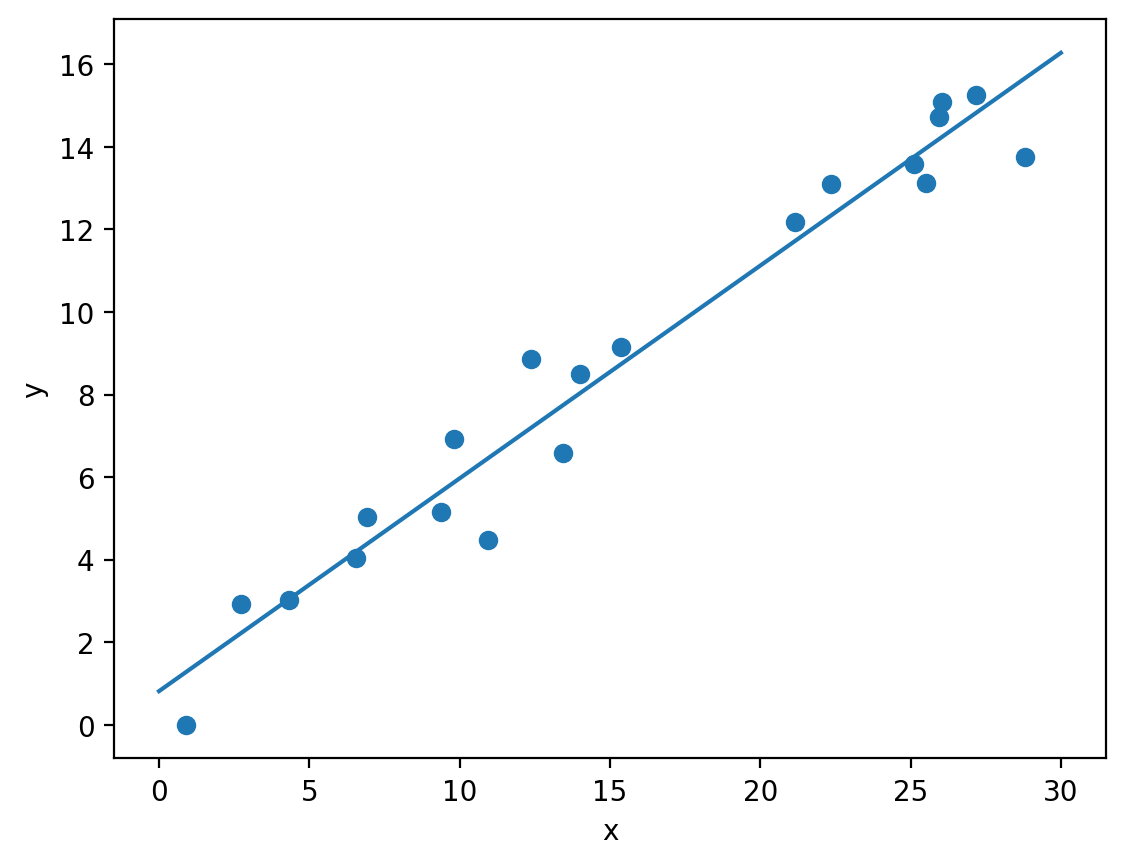

In [126]:
from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'

# G. Richards 2016, based on linear_regression.py by Jake Vanderplas

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

a = 0.5
b = 1.0

# x from 0 to 10
x = 30 * np.random.random(20)

# y = a*x + b with noise
y = a * x + b + np.random.normal(size=x.shape)

# create a linear regression classifier
clf = LinearRegression()
clf.fit(x[:, None], y)

#GTR: Note that these all do the same thing
print(x)
print(x[:, None])
print(x[:, np.newaxis])
print(x.reshape(-1,1))
#But only the first one actually is readable

# predict y from the data
x_new = np.linspace(0, 30, 100)
y_new = clf.predict(x_new[:, None])

# plot the results
ax = plt.axes()
ax.scatter(x, y)
ax.plot(x_new, y_new)

ax.set_xlabel('x')
ax.set_ylabel('y')

ax.axis('tight')
plt.show()

This is all pretty good now, the model has been learned from the training data, and can be used to predict results of test data

### Representation of Data in Scikit-learn

Most algorithms within Scikit learn expect data to be stored in an N dimensional array or matrix, these can either be Numpy arrays or scipy.sparse matrices. The size of the array is expected to be; [n_samples, n_features].

1. **n_samples** Is the number of samples, each sample is an item to process. This can be anything from a document, picture, sound, video, CSV file, or whatever you can describe with a fixed set of quantitative traits.
2. **n_features** is the number of features or distinct traits that can be used to describe each item in a quantitative manner. They can be called "dimensions".


We will first look into the iris dataset within Scikit-Learn.

In [127]:
from sklearn.datasets import load_iris
iris = load_iris()
print(iris.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


The data is the [n_samples, n_features] data array

The target is the outcome that we wish to see, often called the labels.

DESCR is a README file with all the info about the data

We can have a look at this:

In [128]:
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

Let us query the data:

In [129]:
print(iris.data.shape)
n_samples, n_features = iris.data.shape
print(n_samples, n_features)

(150, 4)
150 4


Let us look at the very first row,, and then look at all rows

The very first row shows features for a single sample

And the selection of all rows but 1 column shows samples belonging to a single featuer

In [130]:
print(iris.data[0,:]) 
print(iris.data[:,0])

[5.1 3.5 1.4 0.2]
[5.1 4.9 4.7 4.6 5.  5.4 4.6 5.  4.4 4.9 5.4 4.8 4.8 4.3 5.8 5.7 5.4 5.1
 5.7 5.1 5.4 5.1 4.6 5.1 4.8 5.  5.  5.2 5.2 4.7 4.8 5.4 5.2 5.5 4.9 5.
 5.5 4.9 4.4 5.1 5.  4.5 4.4 5.  5.1 4.8 5.1 4.6 5.3 5.  7.  6.4 6.9 5.5
 6.5 5.7 6.3 4.9 6.6 5.2 5.  5.9 6.  6.1 5.6 6.7 5.6 5.8 6.2 5.6 5.9 6.1
 6.3 6.1 6.4 6.6 6.8 6.7 6.  5.7 5.5 5.5 5.8 6.  5.4 6.  6.7 6.3 5.6 5.5
 5.5 6.1 5.8 5.  5.6 5.7 5.7 6.2 5.1 5.7 6.3 5.8 7.1 6.3 6.5 7.6 4.9 7.3
 6.7 7.2 6.5 6.4 6.8 5.7 5.8 6.4 6.5 7.7 7.7 6.  6.9 5.6 7.7 6.3 6.7 7.2
 6.2 6.1 6.4 7.2 7.4 7.9 6.4 6.3 6.1 7.7 6.3 6.4 6.  6.9 6.7 6.9 5.8 6.8
 6.7 6.7 6.3 6.5 6.2 5.9]


In [131]:
# The shape of the target (labels) array is just a n_samples 1D vector
print(iris.target.shape)

# Here we see that the labels are given numerical values
print(iris.target)

# Use target_names to translate those numerical values to names
print(iris.target_names)
print(iris.target_names[0])

(150,)
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
['setosa' 'versicolor' 'virginica']
setosa


We can see here that 0 = setosa, 1 = Versicolor, 2 = Virginica

Let us visualise this with a scatter plot

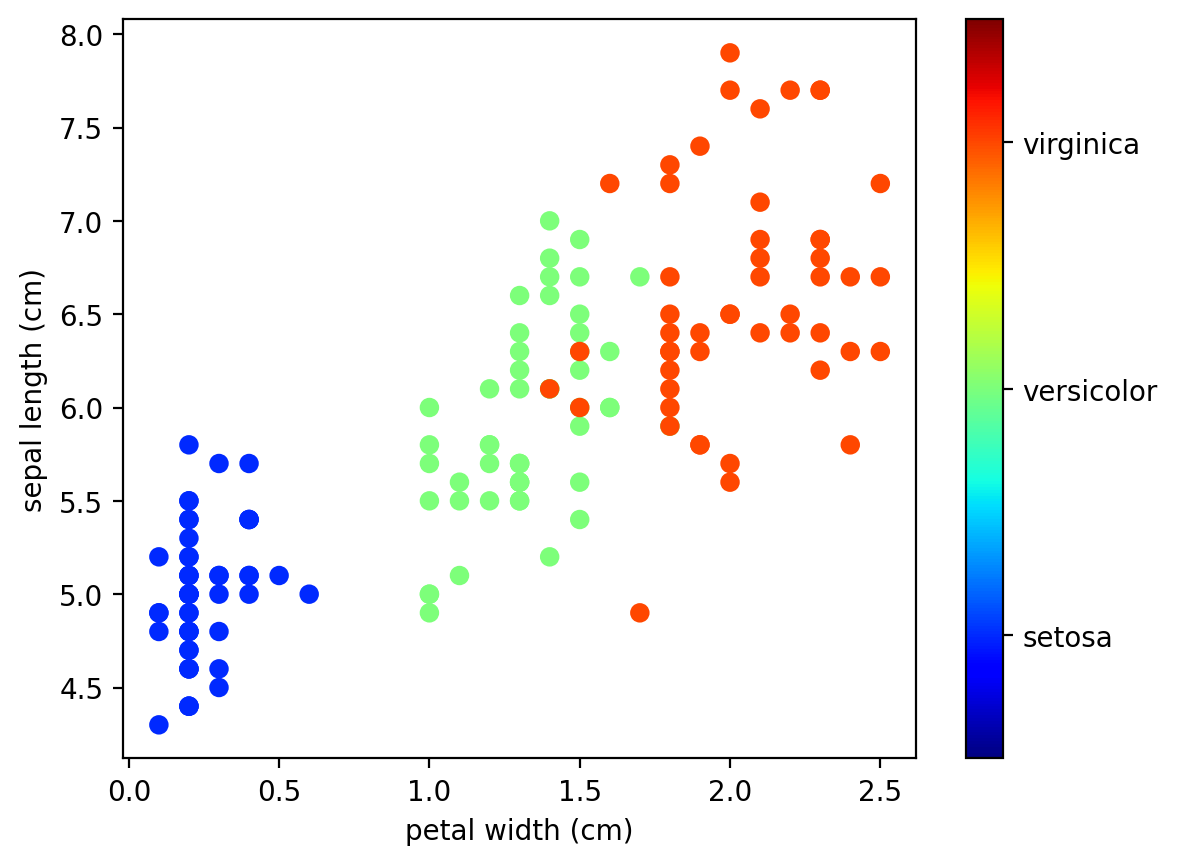

In [132]:
import numpy as np

x_index = 3
y_index = 0

# this formatter will label the colorbar with the correct target names
formatter = plt.FuncFormatter(lambda i, *args: iris.target_names[int(i)])

plt.scatter(iris.data[:, x_index], iris.data[:, y_index], 
            c=iris.target, cmap=plt.colormaps['jet'])

plt.colorbar(ticks=[0, 1, 2], format=formatter)
plt.clim(-0.5, 2.5)
plt.xlabel(iris.feature_names[x_index])
plt.ylabel(iris.feature_names[y_index]);

### Basic Principles of Machine Learning

Every algorithm in Scikit-learn generates an Estimator object, all the parameters of an object can be set when it is instantiated, and have suitable default values.

Let us take a loot at all parameters, attributes and methods in the [Linear Regression module](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)

In [133]:
from sklearn.linear_model import LinearRegression
# Instantiate a LinearRegression estimator object, call it `model`
model = LinearRegression()

print(model)

LinearRegression()


Let us make a simple test case:

[0 1 2 3 4 5 6 7 8 9]
[ 1  3  5  7  9 11 13 15 17 19]


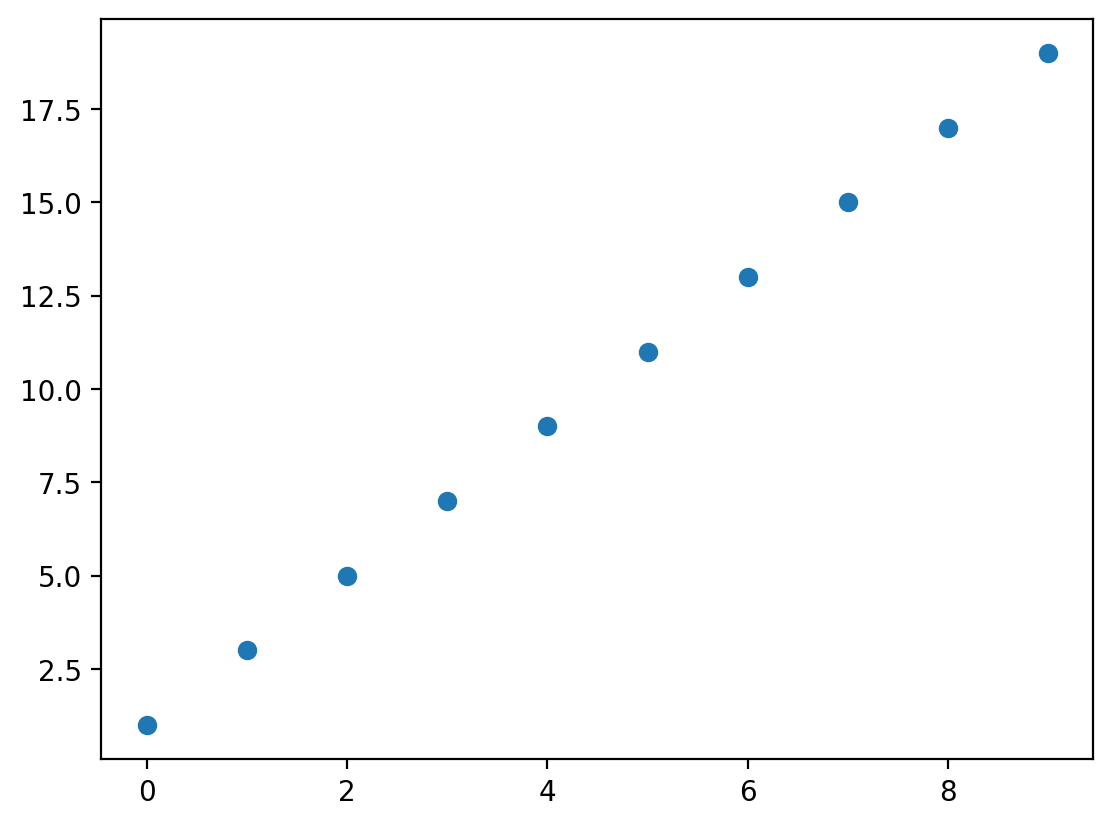

In [134]:
x_train = np.arange(10)    # An array of 10 integers
y_train = 2 * x_train + 1  # Some operation performed on that array
print(x_train)
print(y_train)

plt.plot(x_train, y_train, "o")

Now we wish to fit the data to determine the model parameters that we would need to predict the y values of any new measurement of x

This is done through
1. predicting
2. fitting


In [135]:
# model.fit(x_train, y_train) # here we have a 1D array, but scikit learn wants the training features as a multi dimensional array so we need

x_again = x_train[:, np.newaxis]
print(x_again)

x_again.squeeze()

[[0]
 [1]
 [2]
 [3]
 [4]
 [5]
 [6]
 [7]
 [8]
 [9]]


array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [136]:
# All of these give the same result, just different python ways of writing it 
X = x_train.reshape(-1,1)
X = x_train[:, np.newaxis]
X = x_train[:, None]

y = y_train
print(y)

[ 1  3  5  7  9 11 13 15 17 19]


In [137]:
X=x_train[:,np.newaxis]
model.fit(X, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Seems like it has worked pretty well? What  are the coefficients and the intercept?

In [138]:
# Let's look at the fit parameters, which are indicated by an underscore at the end
print(model.coef_)
print(model.intercept_)

[2.]
0.9999999999999982


Now that we have the model, we can use it to predict things!

In [139]:
model.predict([[3.45]])

array([7.9])

We use [[3.45]] as scikit learn expects the input data to be a 2D array, 3.45 would just be a scalar, [3.45] would be a 1D array.

So we have the outer brackets that show the rows (samples), and the inner brackets that represent the columnes (features). This makes the shape (1,1)

In [140]:
x = [[3.45]]
x = np.array(x)
x.shape

(1, 1)

### Supervised Learning: Classification and Regression

Our task within supervised learning, is that for a given data set with features and labels, to construct an estimator that is able to predict the label of an object given the set of features.

#### Classification Example

In [141]:
from sklearn import neighbors, datasets

iris = datasets.load_iris()

x,y = iris.data, iris.target

knn = neighbors.KNeighborsClassifier(n_neighbors=5)

knn.fit(x,y)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


So we have this now, we can go into the predictive stage, so what kind of iris has a 3cm x 5cm sepal and a 4xm x 2cm petal?

In [142]:
Xtest=[[3,5,4,2]]

result = knn.predict(Xtest)
print(result)
print(iris.target_names[result]) # Complete such that the name rather than the number is output.

[1]
['versicolor']


What if we want a probabilistic prediction instead of a exact one?

In [143]:
knn.predict_proba(Xtest)

array([[0. , 0.8, 0.2]])

We read this as 0% chance of class 0, 80% chance of class 1, and 20% chance of class

We can even see this more thoroughly by showing the full parameter space:

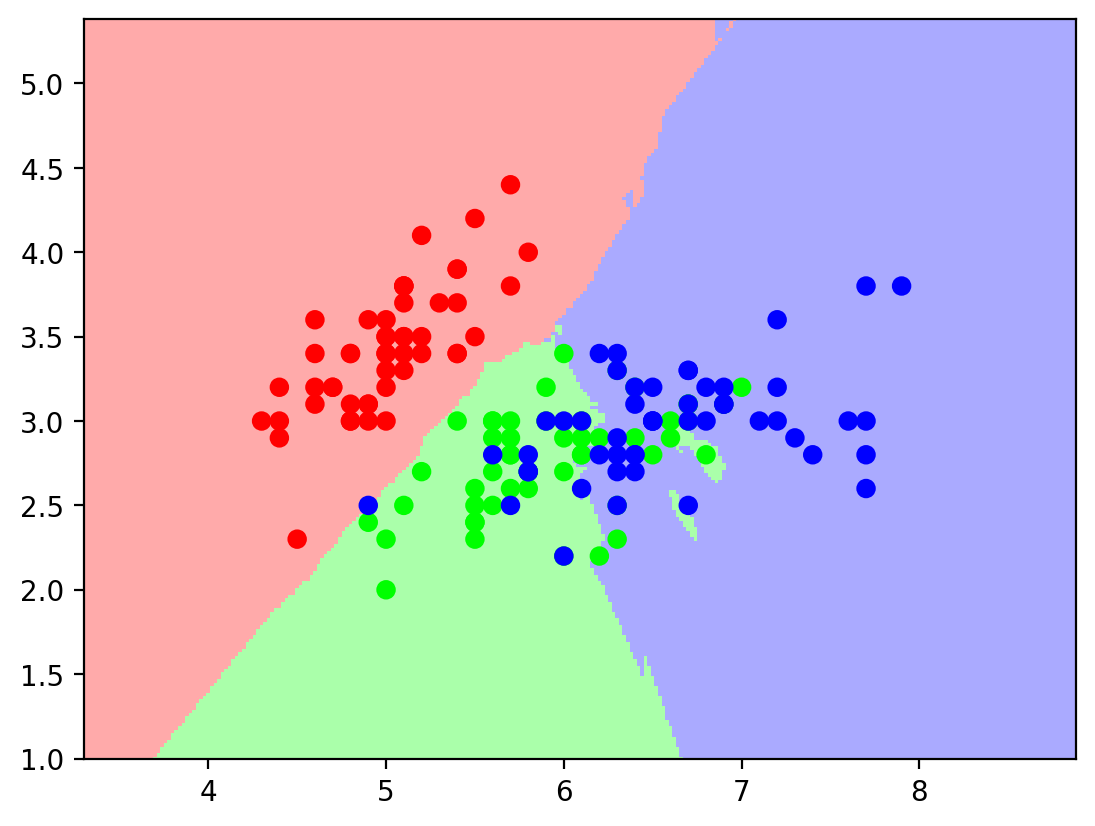

In [144]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn import neighbors, datasets

n_neighbors = 15

# import some data to play with
iris = datasets.load_iris()

# we only take the first two features
X = iris.data[:, :2]  
y = iris.target

h = .02  # step size in the mesh

# Create color maps
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

# we create an instance of Neighbours Classifier and fit the data.
model =  neighbors.KNeighborsClassifier(n_neighbors)
model.fit(X, y)

# Plot the decision boundary. For that, we will assign a color to each
# point in the mesh [x_min, x_max]x[y_min, y_max].

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])

# Put the result into a color plot
Z = Z.reshape(xx.shape)
plt.figure()
plt.pcolormesh(xx, yy, Z, cmap=cmap_light, shading='auto')

#Now overplot the training points                     
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())

plt.show()

We can do the exact same using [support vector machine calculation](https://scikit-learn.org/stable/modules/svm.html)

In [145]:
from sklearn.svm import SVC
iris = datasets.load_iris()
X, y = iris.data, iris.target
Xtest = np.array([[3,5,4,2],])

model = SVC()
model.fit(X,y)
result = model.predict(Xtest)
print(iris.target_names[result])

['versicolor']


This predicted what type of iris has a 3cm x 5cm sepal and a 4cm x 2cm petal.

#### Regression Example

The simplest possible regression example is fitting a line to data:

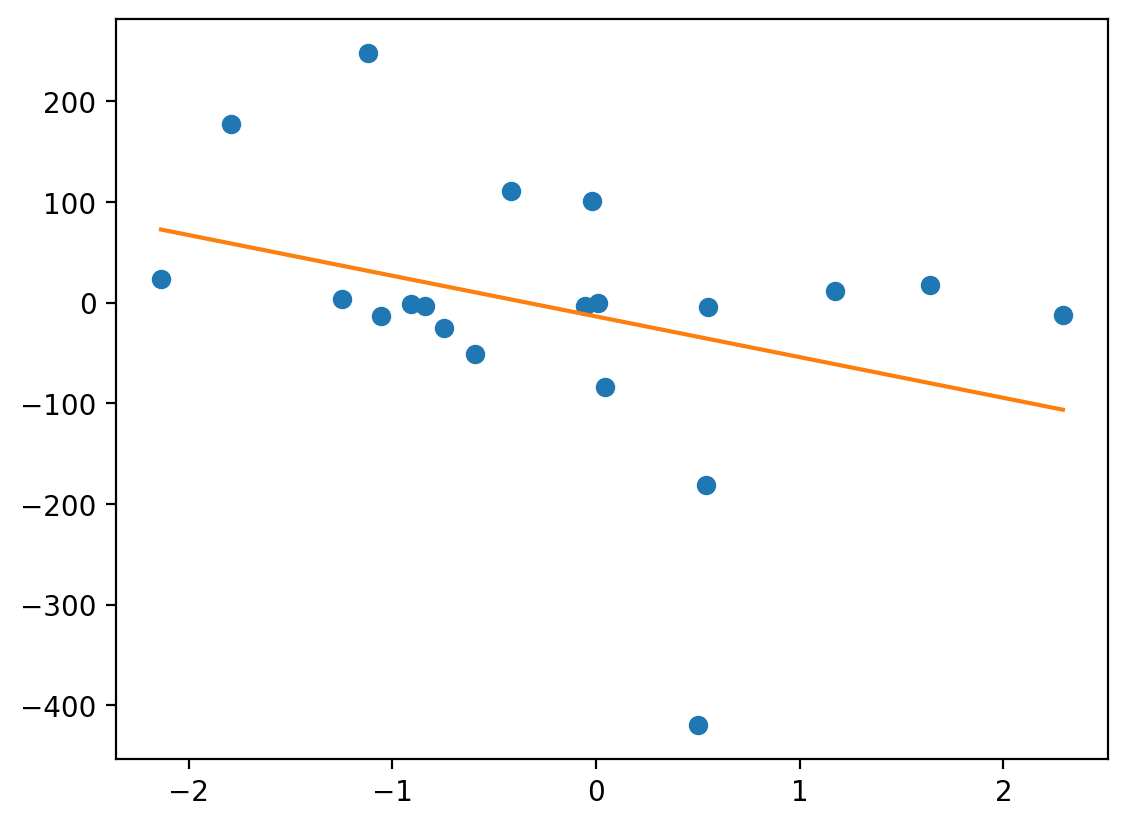

In [146]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

# Create some simple data

np.random.seed(2)
x = np.random.normal(size=20) # 30 random numbers between 0 an 1
y = 3 * x + 2 + np.random.standard_cauchy(20)*np.random.normal(20) # some operation performed on that array
X = x[:,np.newaxis]

# Fit a Linear Regression
modelLR = LinearRegression()
#modelRF = 
modelLR.fit(X,y)

# Plot the data and the model prediction
x_test = np.linspace(x.min(), x.max(), 100)
X_test = x_test[:,np.newaxis]
y_predLR = modelLR.predict(X_test)

plt.plot(x, y, 'o')
plt.plot(X_test, y_predLR)

Now we will add to the code to implement a randomforestregressor from sklearn.ensemble. [From here](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html)

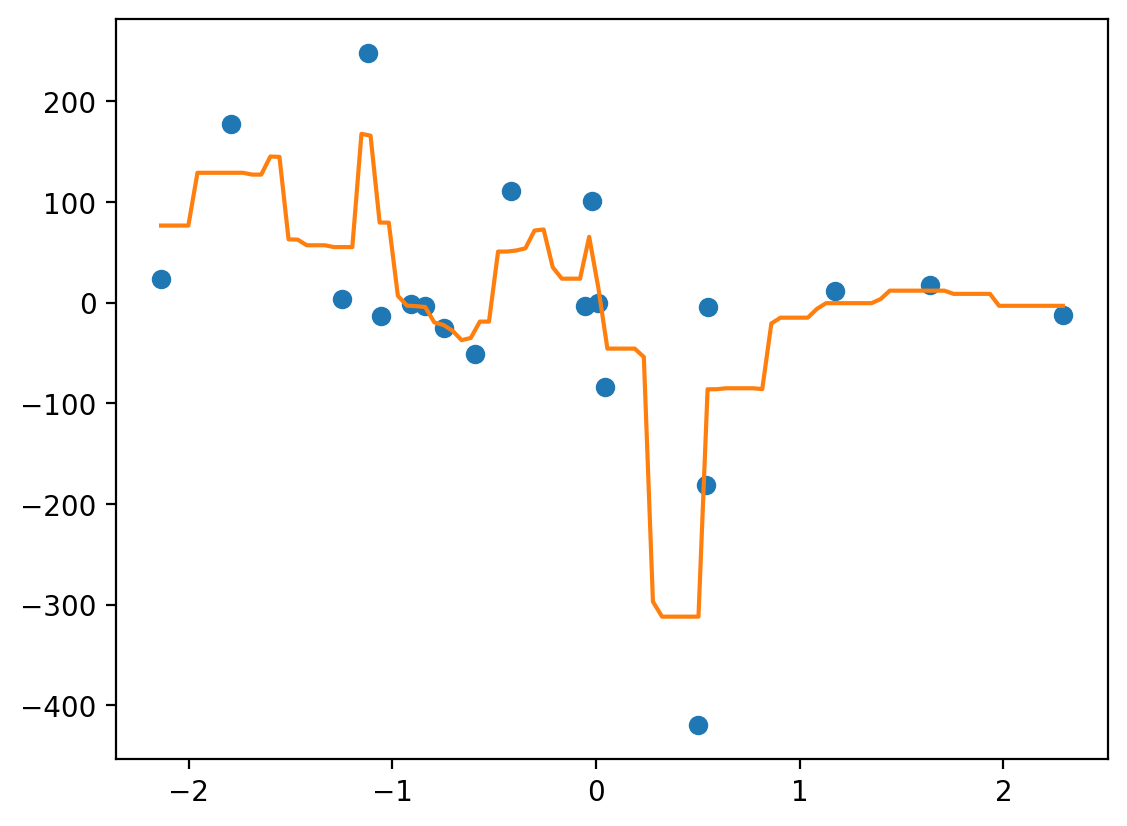

In [147]:
from sklearn.ensemble import RandomForestRegressor 

# Fit a Linear Regression
modelLR = RandomForestRegressor()
#modelRF = 
modelLR.fit(X,y)

# Plot the data and the model prediction
x_test = np.linspace(x.min(), x.max(), 100)
X_test = x_test[:,None]
y_predLR = modelLR.predict(X_test)

plt.plot(x, y, 'o')
plt.plot(X_test, y_predLR)

### What about Unsupervised Learning?

1. The data has no labels
2. We are interested in finding similarities between the objects 
3. You can think of it as discovering labels from the data itself

This term includes: **dimensionality reduction**, **clustering** and **density estimation**

#### Dimensionality Reduction: PCA

[Principle Component Analysis](https://scikit-learn.org/stable/modules/decomposition.html#principal-component-analysis-pca) is a dimensional reduction technique that can find the combinations of variables that explain the most variance. 

The process starts with:



In [148]:
X, y = iris.data, iris.target
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca.fit(X)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",2
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

A lot if it just comes to fitting it using a specific command, and then predicting an outcome.

However, here we can't do that as we do not have training data, so we are going to use something called transform() which is found in PCA.

Reduced dataset shape: (150, 2)
Projection of the 2 components:
0.361 x sepal length (cm) + -0.085 x sepal width (cm) + 0.857 x petal length (cm) + 0.358 x petal width (cm)
0.657 x sepal length (cm) + 0.730 x sepal width (cm) + -0.173 x petal length (cm) + -0.075 x petal width (cm)


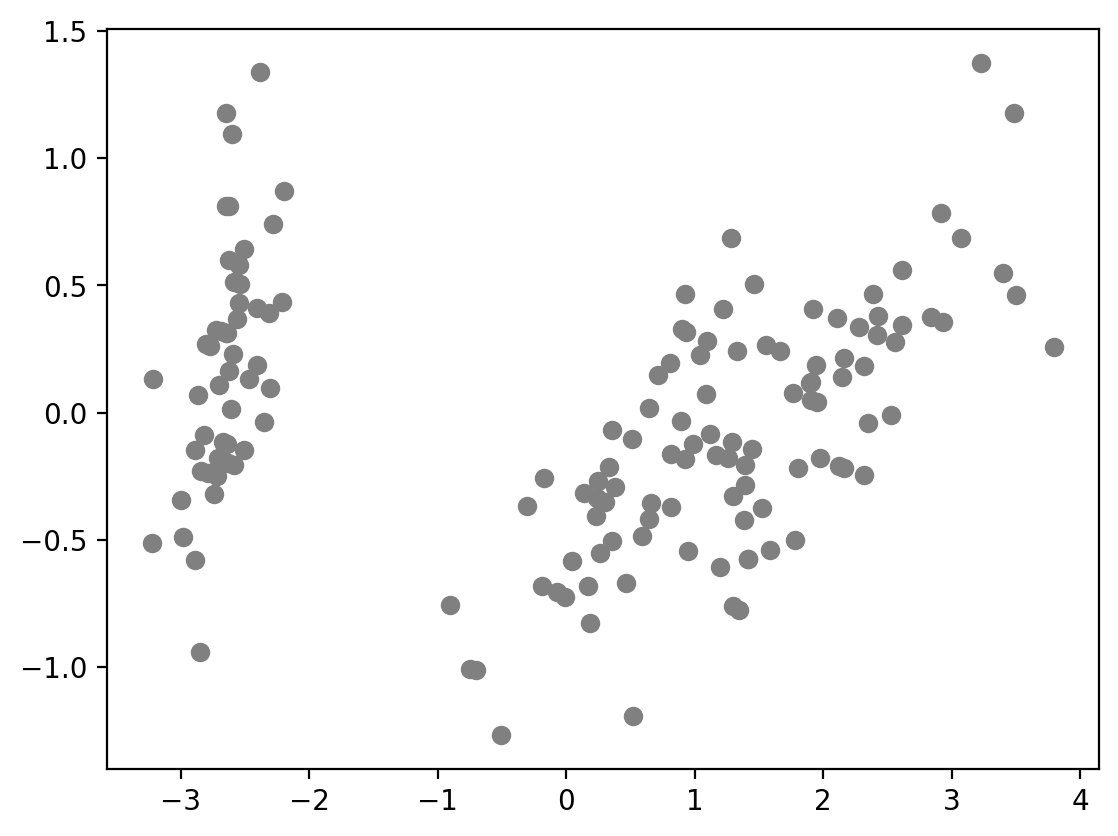

In [149]:
X_reduced = pca.transform(X)
print("Reduced dataset shape:", X_reduced.shape)

plt.scatter(X_reduced[:, 0], X_reduced[:, 1], 
            c='gray')

print("Projection of the 2 components:")
for component in pca.components_:
    print(" + ".join("%.3f x %s" % (value, name) for value, name in 
                     zip(component, iris.feature_names)))

- This projection maximised the variation of the classes without knowing lables, and this made it seem to maximise the separation
- We can use this for visualisation or to help define classes
- From this we can see there are definitely either 2 or 3 classes.



### Clustering - K means

Clustering groups together observations that are homogeneous with respect to a given criterion.

We are looking at [KMeans](https://scikit-learn.org/stable/modules/clustering.html#k-means) clustering.




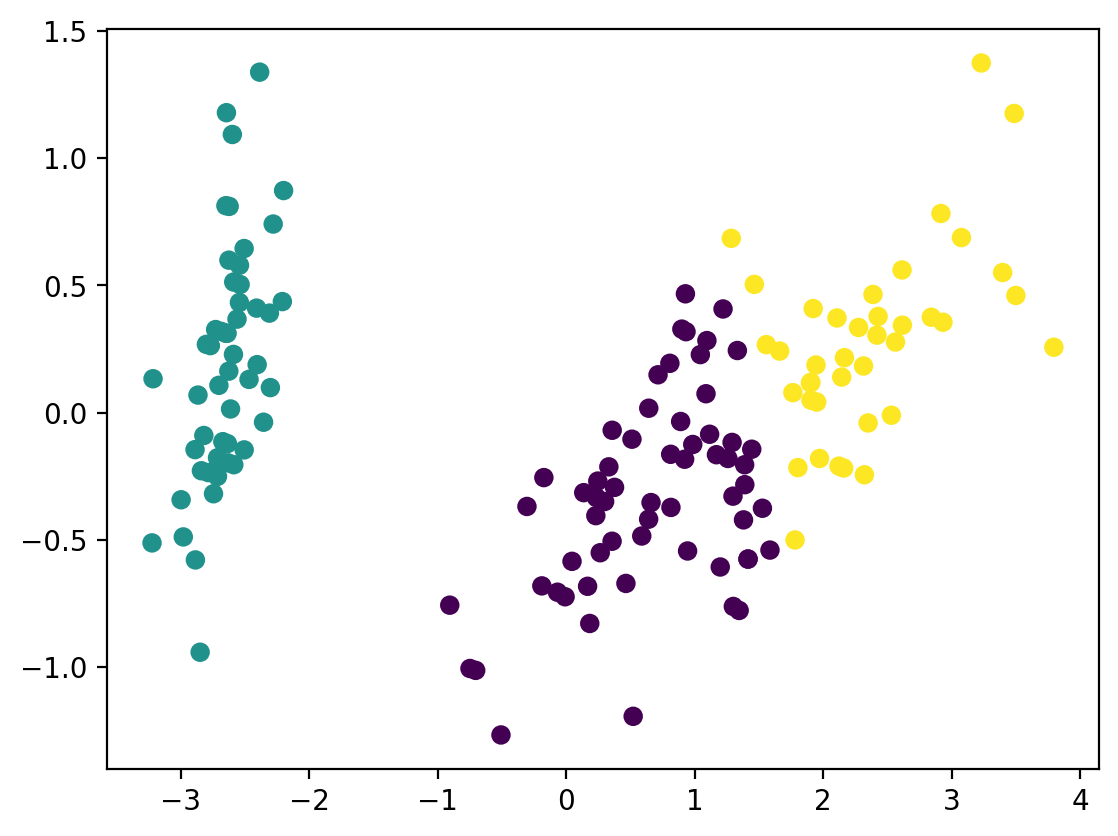

In [150]:
from sklearn.cluster import KMeans

k_means = KMeans(n_clusters=3,n_init='auto')
k_means.fit(X_reduced)
y_pred = k_means.predict(X_reduced)

plt.scatter(X_reduced[:, 0], X_reduced[:, 1], 
            c=y_pred, cmap='viridis');

The colours here are the predictions, and we asked it to find 3 initially and so it gave us 3 different regions. Try a higher value like I did.

What about their true values?

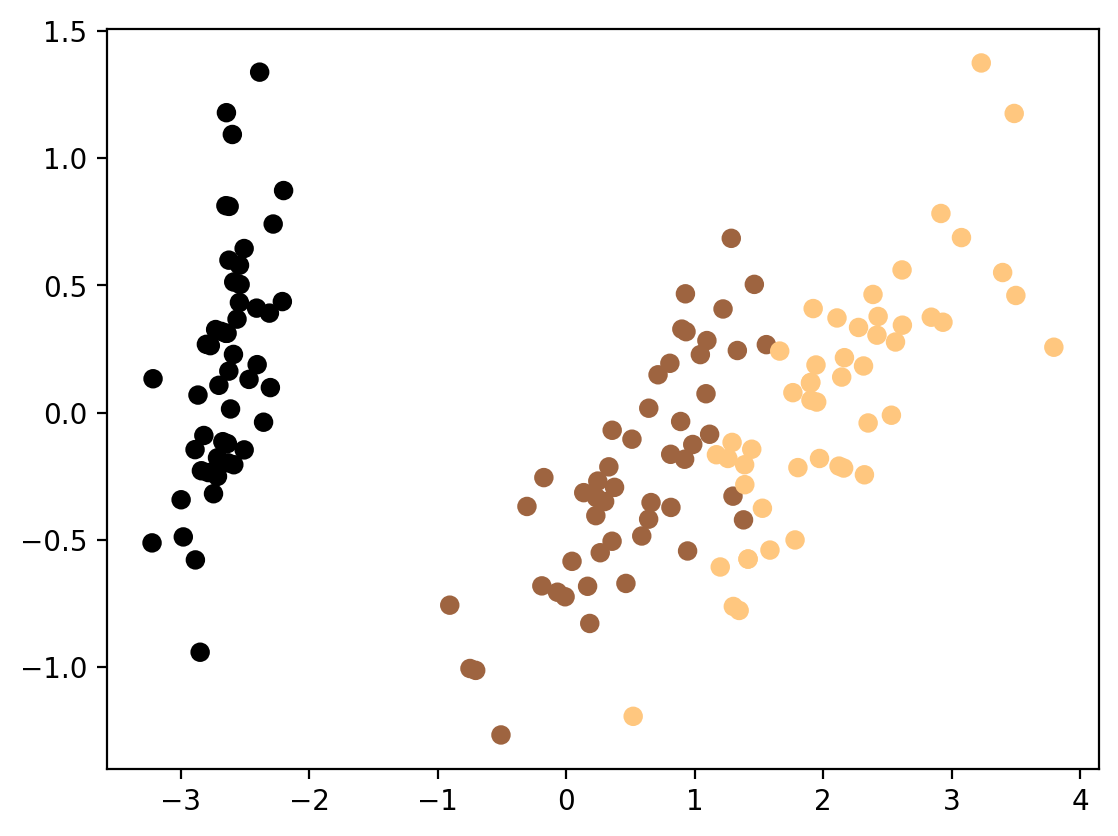

In [151]:
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], 
            c=y, cmap="copper")

### Scikit-learn Estimator Interface

Scikit-learn uses a similar structure for most machine learning models.

#### Main methods

- model.fit() trains the model on data
- model.predict() makes predictions using the trained model
- model.predict_proba() gives the probability of each class
- model.score() measures how well the model performs
- model.transform() transforms data using what the model has learned
- model.fit_transform() fits and transforms the data in one step

#### Supervised learning

model.fit(X, y)

X = input features  
y = known labels or values

The model learns the relationship between X and y.

#### Unsupervised learning

model.fit(X)

There is no y because there are no known labels.

#### Key idea

fit learns from the data  
predict makes predictions  
transform changes the representation of the data  
score evaluates the model

### Model Validation

THis is very important as you wish to determine how well your model wil generalize training data to future unlabeled data.


Lets use the nearest neighbour classifier as an example:

In [152]:
from sklearn.neighbors import KNeighborsClassifier
X, y = iris.data, iris.target
clf = KNeighborsClassifier(n_neighbors=1)
clf.fit(X, y)
y_pred = clf.predict(X)
print('Element-wise check: ' + str(y==y_pred))
print('All-at-once check: ' + str(np.all(y == y_pred))) # To check all at once.

Element-wise check: [ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True]
All-at-once check: True


A good way of looking at it is using a confusion matrix, or the matrix showing the frequency of input and output.

In [153]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y, y_pred))

[[50  0  0]
 [ 0 50  0]
 [ 0  0 50]]


This shows a perfect classification, where all 150 instances are correly identified along the diagonal. This is as it was done on its own training data.

As we talked about before, we can split the data into a training set and a test set, this is how we do it.

In [154]:
from sklearn.model_selection import train_test_split
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y,test_size=0.5)
clf.fit(Xtrain, ytrain)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [155]:
ypred = clf.predict(Xtrain)
print(confusion_matrix(ytrain, ypred))

[[26  0  0]
 [ 0 22  0]
 [ 0  0 27]]


This model correctly classifies every sample in the training, as the diagonals all sum to 75.

In [156]:
ypred = clf.predict(Xtest)
print(confusion_matrix(ytest, ypred))

[[24  0  0]
 [ 0 26  2]
 [ 0  2 21]]


This is the true test, it seems like it classifies the 1st set somewhat okay, and then there are errors with the 2nd and 3rd as some are misclassified as each other.

This is why we should use a train/test split when evaluating models!

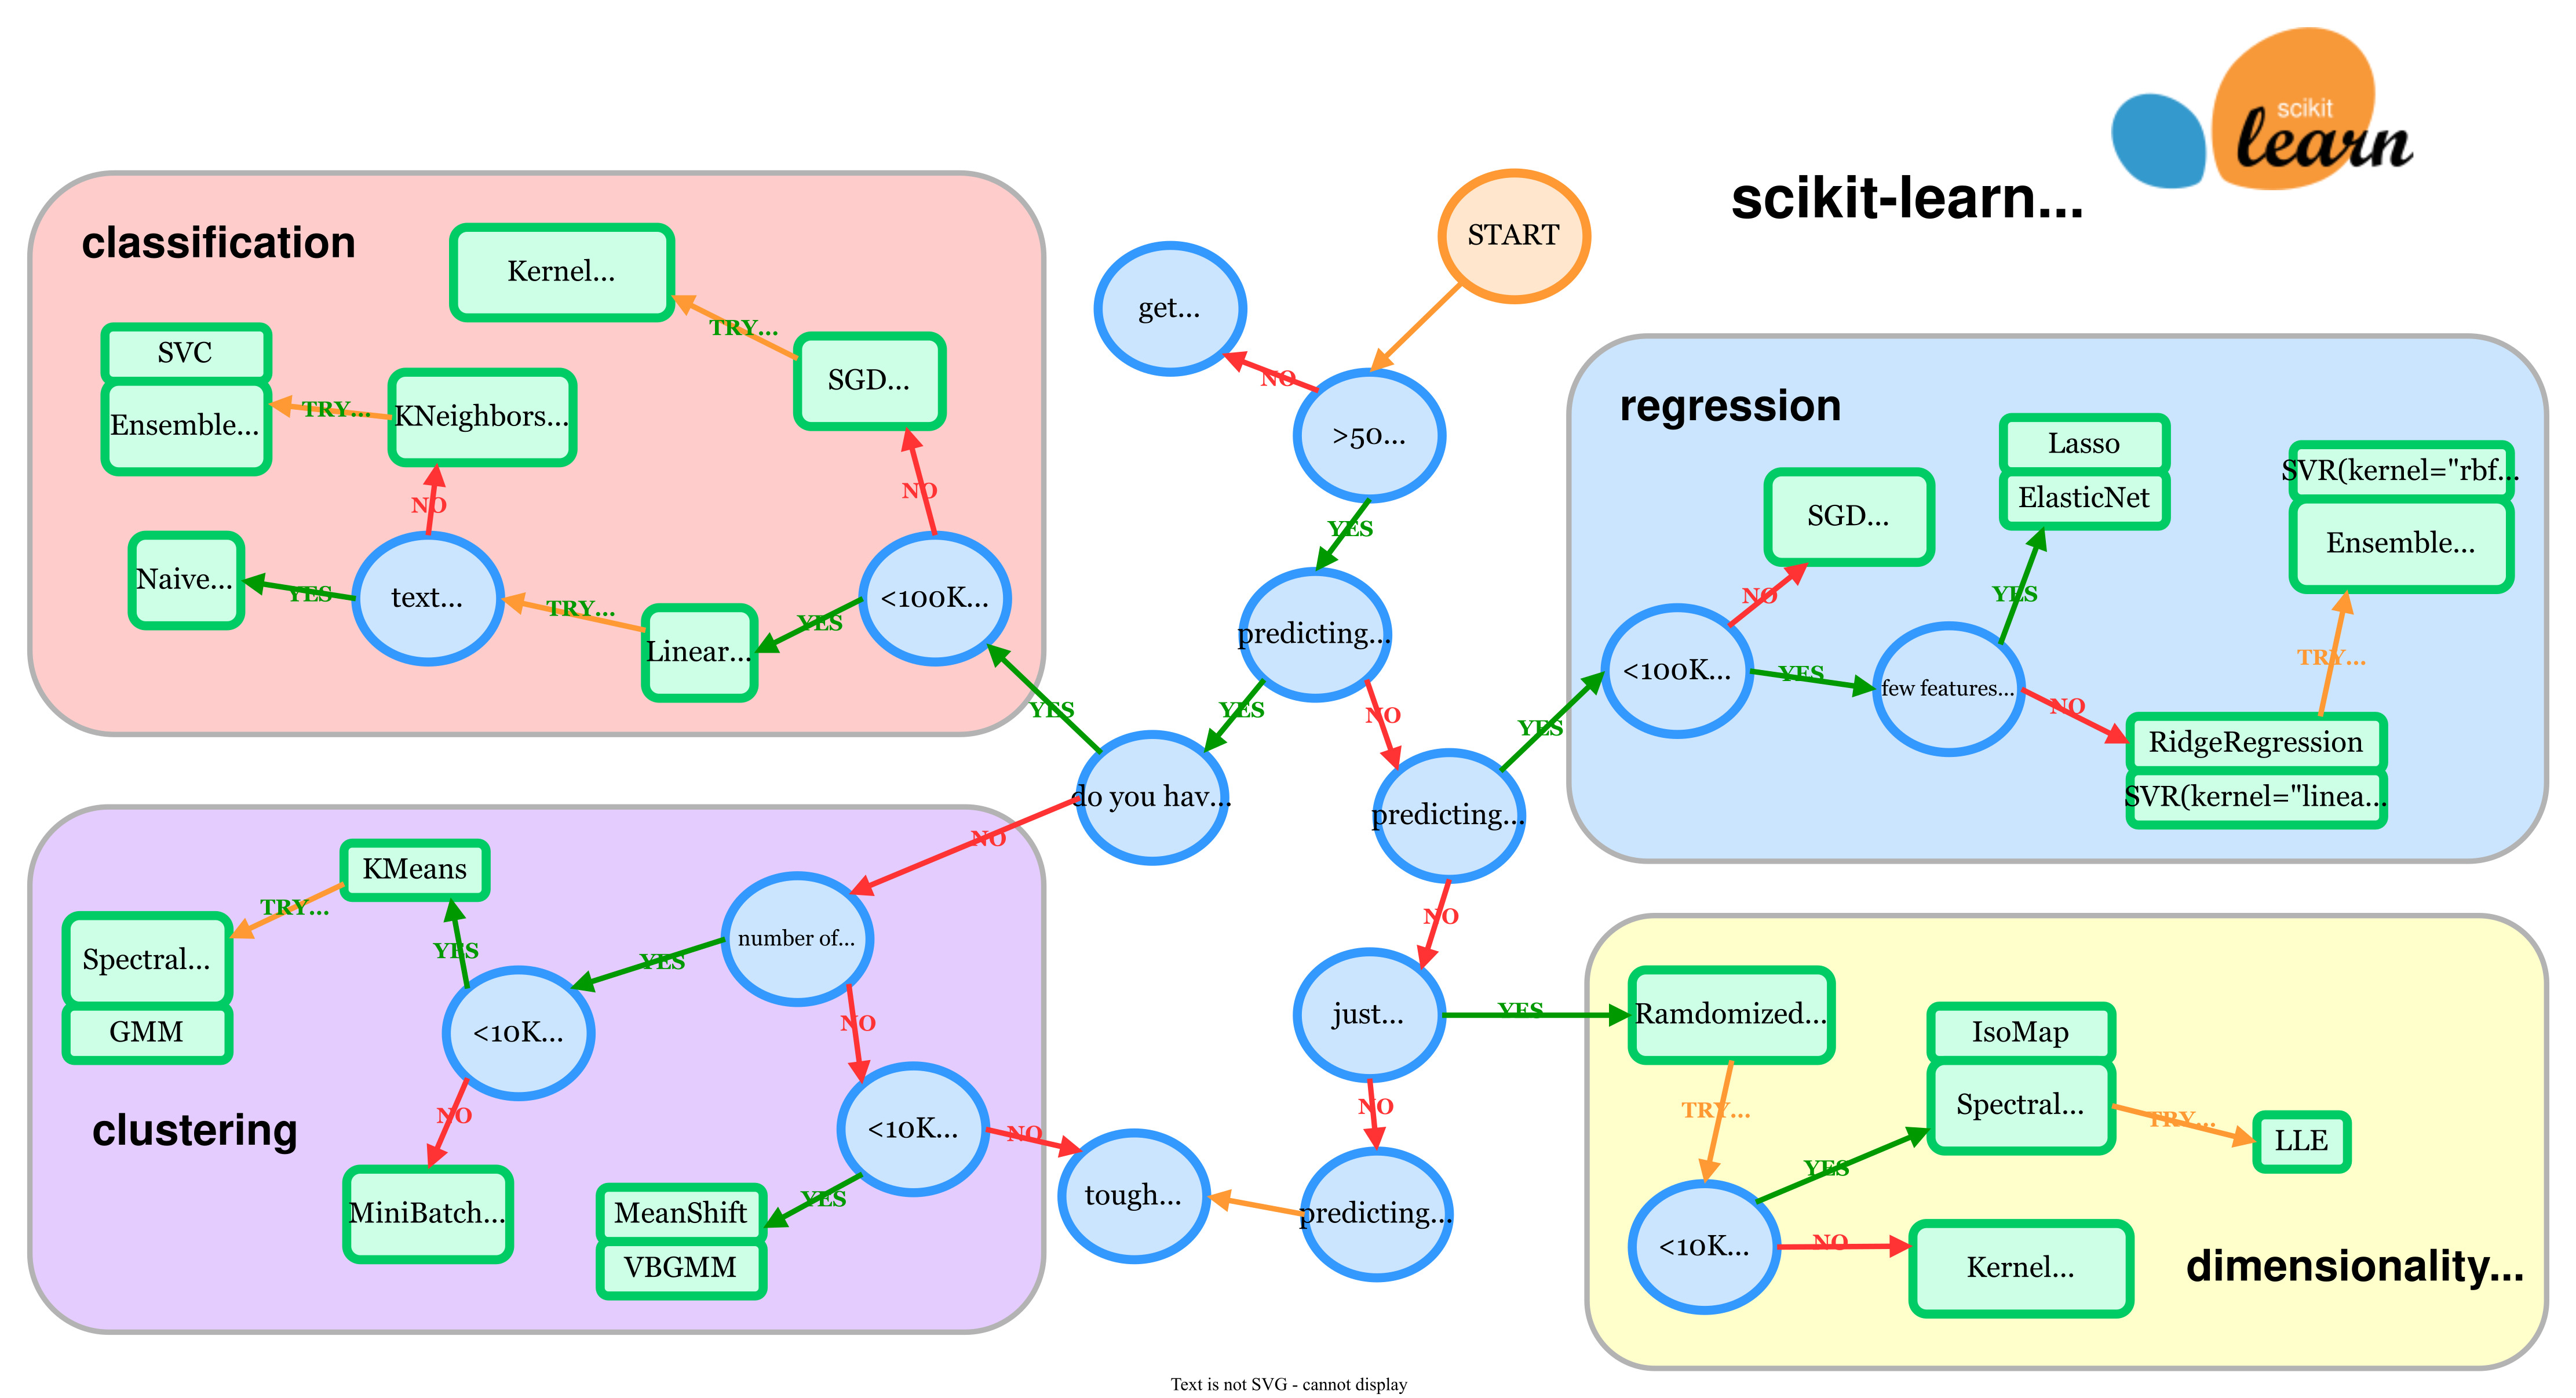